
Evaluating pima dataset...

Evaluating breast_cancer dataset...

Evaluating heart_disease dataset...

Results for pima dataset:
Logistic Regression:
    Accuracy: 0.7532
    Precision: 0.6491
    Recall: 0.6727
    F1 Score: 0.6607
SVM:
    Accuracy: 0.7273
    Precision: 0.6327
    Recall: 0.5636
    F1 Score: 0.5962
Decision Tree:
    Accuracy: 0.7532
    Precision: 0.6349
    Recall: 0.7273
    F1 Score: 0.6780
Random Forest:
    Accuracy: 0.7273
    Precision: 0.6182
    Recall: 0.6182
    F1 Score: 0.6182

Results for breast_cancer dataset:
Logistic Regression:
    Accuracy: 0.9737
    Precision: 0.9722
    Recall: 0.9859
    F1 Score: 0.9790
SVM:
    Accuracy: 0.9737
    Precision: 0.9722
    Recall: 0.9859
    F1 Score: 0.9790
Decision Tree:
    Accuracy: 0.9386
    Precision: 0.9571
    Recall: 0.9437
    F1 Score: 0.9504
Random Forest:
    Accuracy: 0.9649
    Precision: 0.9589
    Recall: 0.9859
    F1 Score: 0.9722

Results for heart_disease dataset:
Logistic Regression:
  

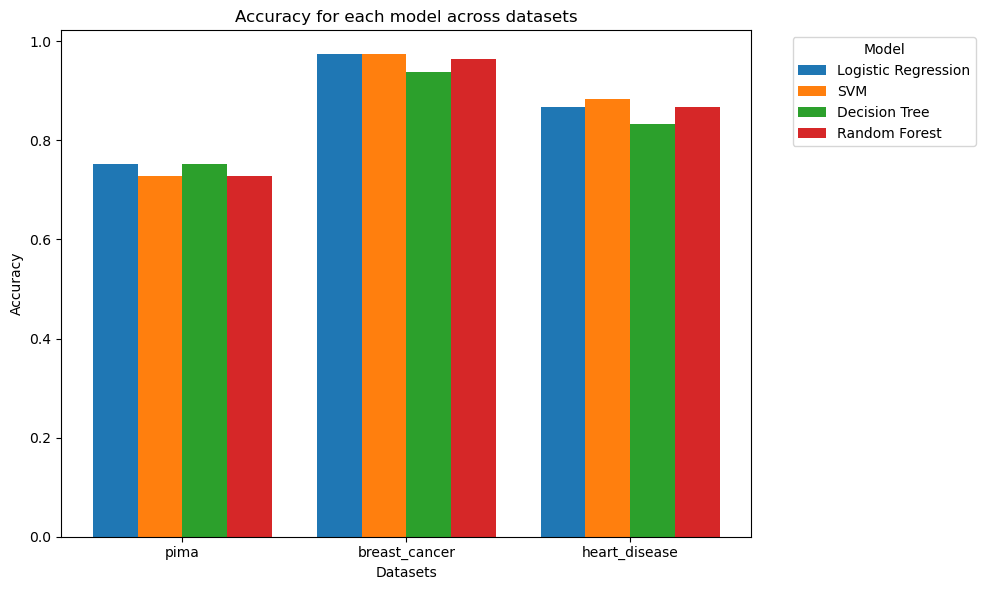

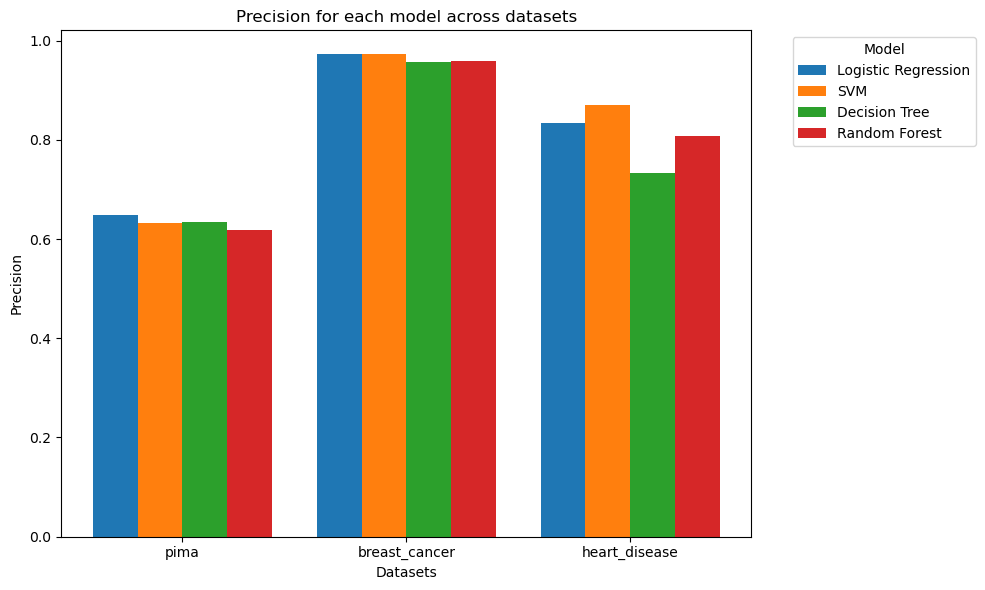

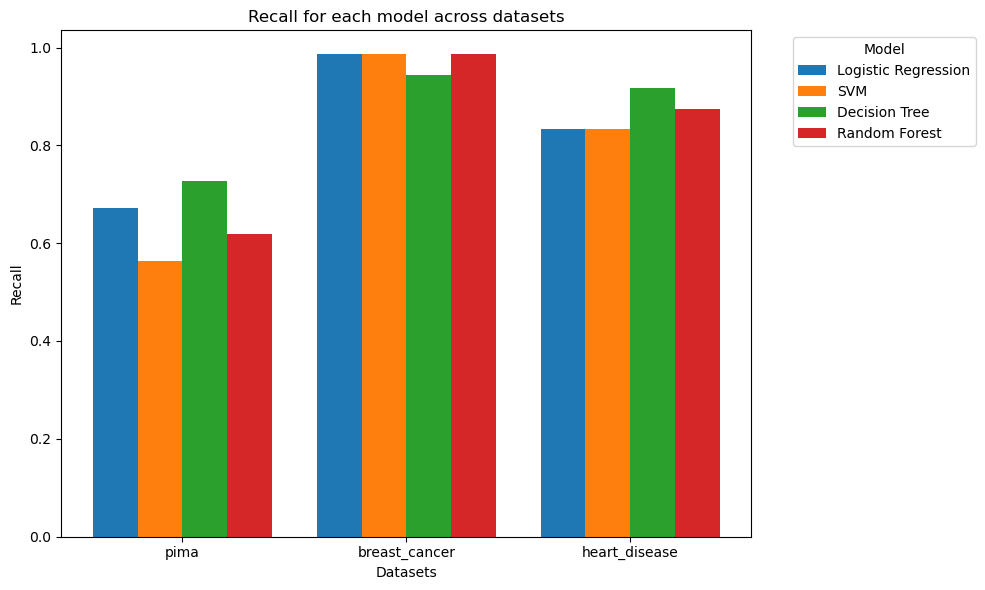

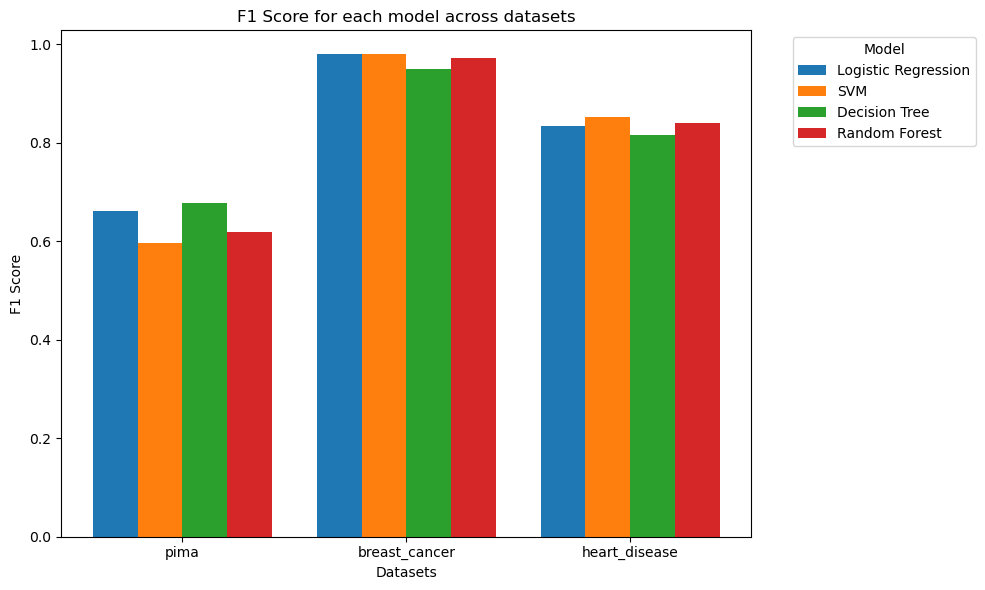

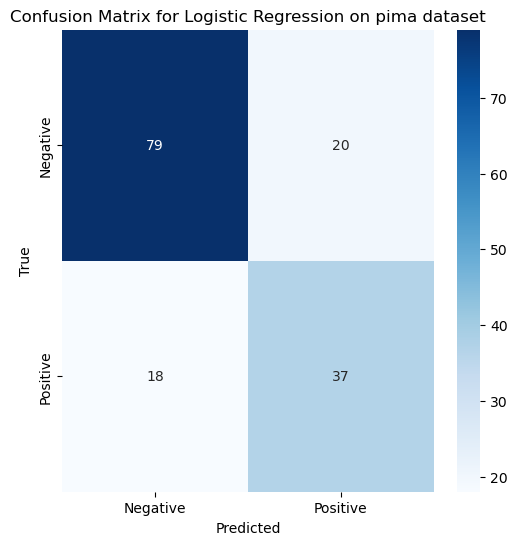

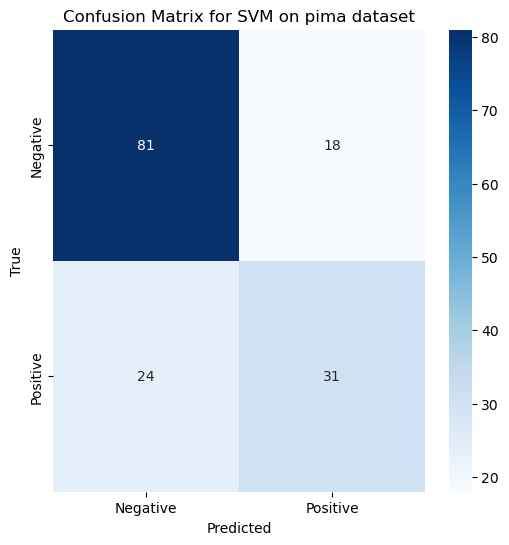

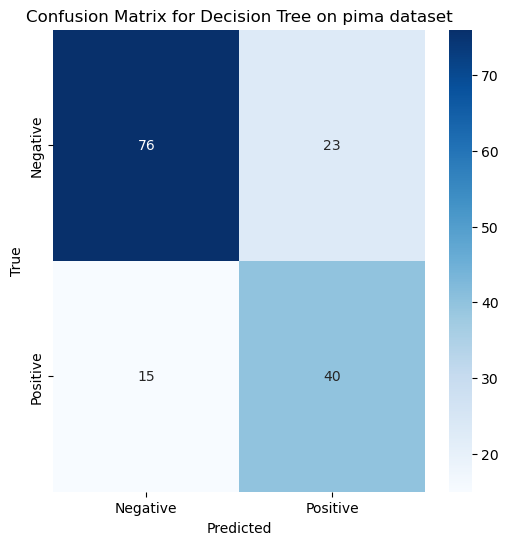

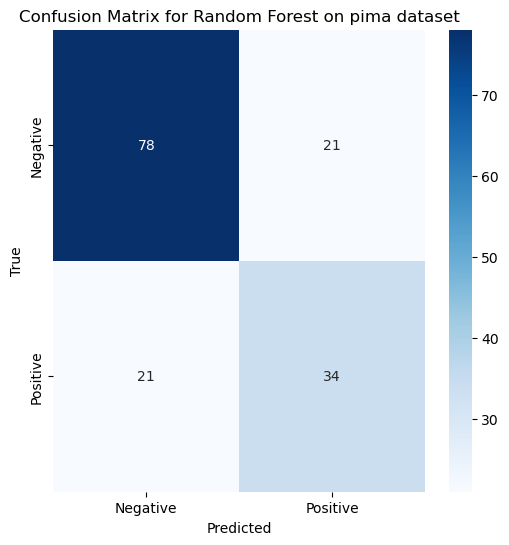

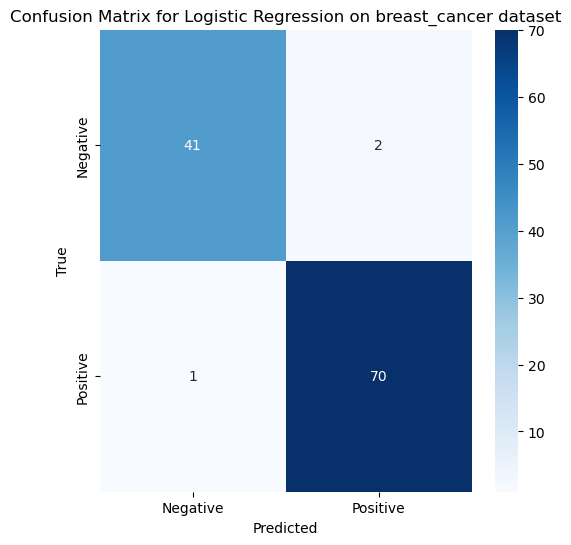

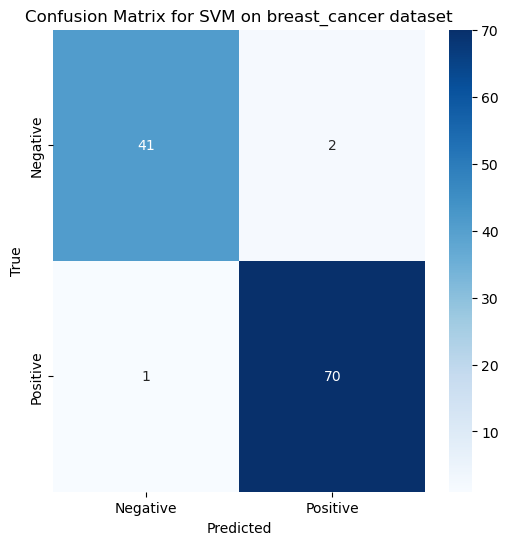

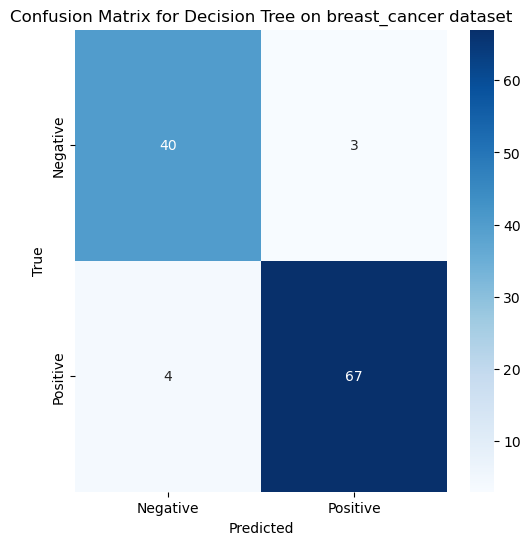

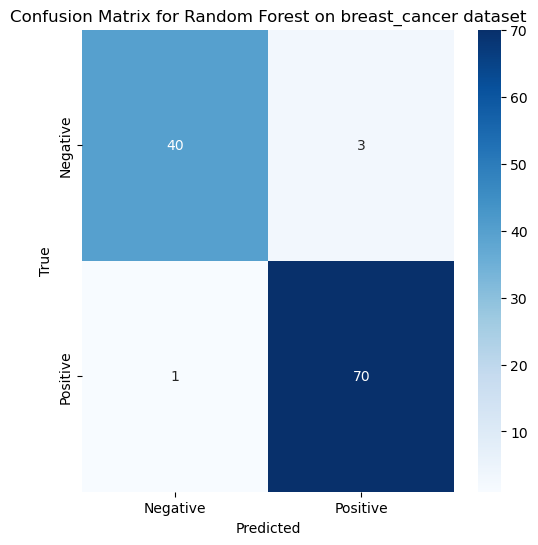

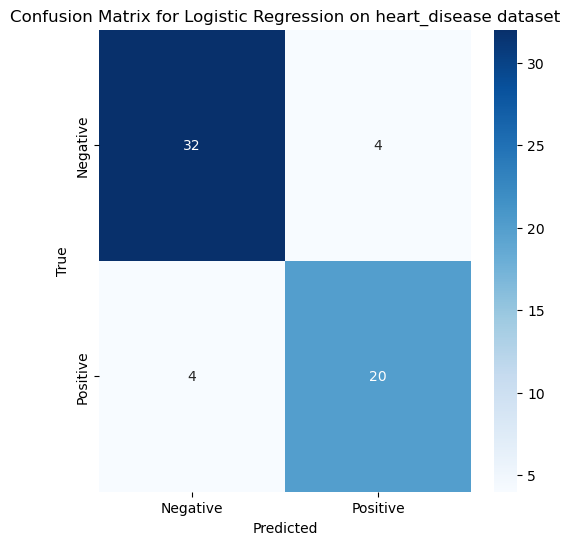

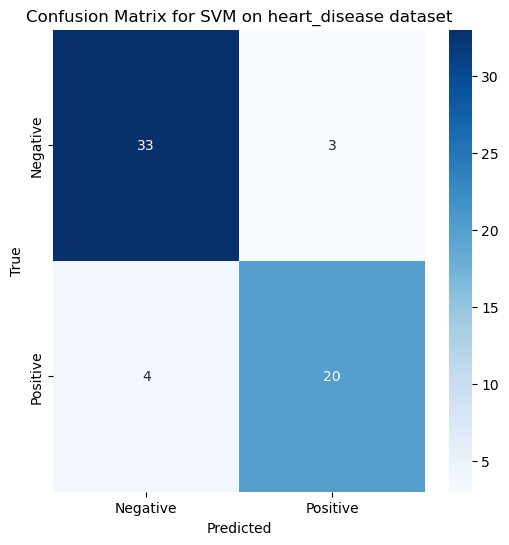

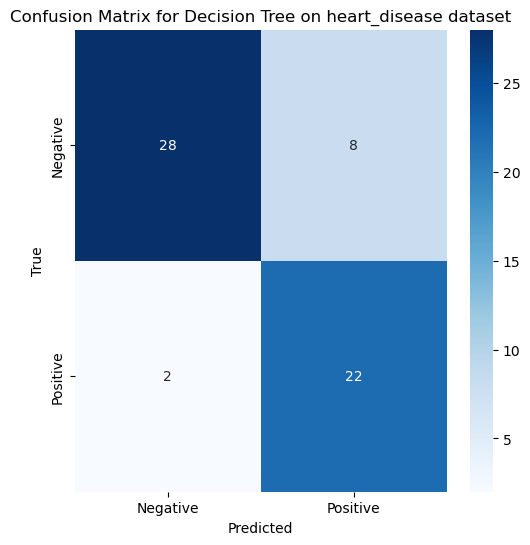

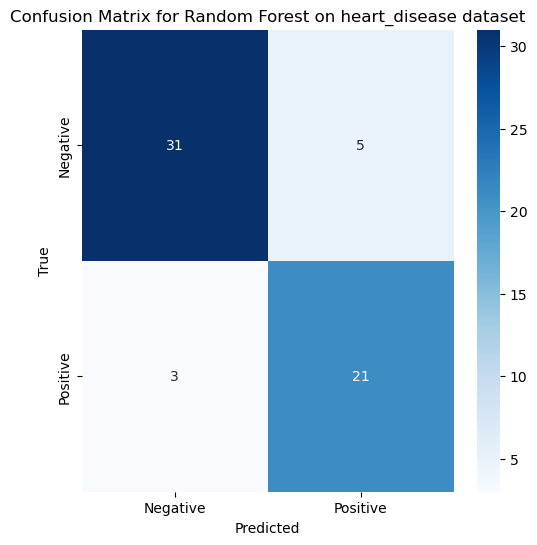

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

# Function to load the Pima Indians Diabetes dataset
def load_pima_dataset():
    url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
    columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
    data = pd.read_csv(url, header=None, names=columns)
    return data

# Function to load the Breast Cancer dataset from sklearn
def load_breast_cancer_dataset():
    data = load_breast_cancer()
    # Convert to DataFrame
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['Class'] = data.target
    return df

# Function to load the Heart Disease dataset
def load_heart_disease_dataset():
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
    columns = ['Age', 'Sex', 'Cp', 'Trestbps', 'Chol', 'Fbs', 'Restecg', 'Thalach', 'Exang', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'Target']
    data = pd.read_csv(url, header=None, names=columns)
    data.replace('?', np.nan, inplace=True)
    data.dropna(inplace=True)
    data['Target'] = data['Target'].apply(lambda x: 1 if x > 0 else 0)  # binary classification
    return data

# Function to load a dataset based on name
def load_dataset(dataset_name):
    if dataset_name == 'pima':
        data = load_pima_dataset()
    elif dataset_name == 'breast_cancer':
        data = load_breast_cancer_dataset()
    elif dataset_name == 'heart_disease':
        data = load_heart_disease_dataset()
    else:
        raise ValueError("Dataset name not recognized.")
    return data

# Function to preprocess data (separate features and target)
def preprocess_data(data, target_column):
    X = data.drop(target_column, axis=1)
    y = data[target_column]
    return X, y

# Function to train and evaluate models
def evaluate_models(X_train, X_test, y_train, y_test):
    models = {
        'Logistic Regression': LogisticRegression(max_iter=500),  # Increased max_iter
        'SVM': SVC(),
        'Decision Tree': DecisionTreeClassifier(),
        'Random Forest': RandomForestClassifier()
    }
    
    results = {}
    confusion_matrices = {}
    
    # Train and evaluate each model
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results[model_name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1
        }
        
        # Store confusion matrix
        confusion_matrices[model_name] = confusion_matrix(y_test, y_pred)
    
    return results, confusion_matrices

# Function to plot the results (accuracy, precision, recall, f1 score) for each model across datasets
def plot_results(results_summary):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    
    # Set the width of the bars
    bar_width = 0.2
    # Set positions of bars on x-axis
    index = np.arange(len(results_summary))  # Number of datasets
    model_names = list(results_summary[list(results_summary.keys())[0]].keys())  # List of models
    
    # Plot grouped bars
    for i, metric in enumerate(metrics):
        plt.figure(figsize=(10, 6))
        
        # Offset for each metric to align bars for each model
        for j, model_name in enumerate(model_names):
            # Retrieve metric value for each model and dataset
            values = [results[model_name][metric] for dataset_name, results in results_summary.items()]
            plt.bar(index + j * bar_width, values, bar_width, label=model_name)
        
        # Add labels, title, etc.
        plt.xlabel('Datasets')
        plt.ylabel(metric)
        plt.title(f'{metric} for each model across datasets')
        plt.xticks(index + bar_width * (len(model_names) - 1) / 2, results_summary.keys())  # Center dataset names
        plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

# Function to plot confusion matrices
def plot_confusion_matrices(confusion_matrices_summary):
    for dataset_name, matrices in confusion_matrices_summary.items():
        for model_name, cm in matrices.items():
            plt.figure(figsize=(6, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
            plt.title(f'Confusion Matrix for {model_name} on {dataset_name} dataset')
            plt.xlabel('Predicted')
            plt.ylabel('True')
            plt.show()

# List of datasets to evaluate
datasets = ['pima', 'breast_cancer', 'heart_disease']

# Dictionary to store results and confusion matrices
results_summary = {}
confusion_matrices_summary = {}

# Loop through datasets and evaluate models
for dataset_name in datasets:
    print(f'\nEvaluating {dataset_name} dataset...')
    
    # Load dataset
    data = load_dataset(dataset_name)
    
    # Determine target column for each dataset
    if dataset_name == 'pima':
        target_column = 'Outcome'
    elif dataset_name == 'breast_cancer':
        target_column = 'Class'
    elif dataset_name == 'heart_disease':
        target_column = 'Target'
    
    # Preprocess data
    X, y = preprocess_data(data, target_column)
    
    # Scale the data (standardization)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)  # Scale the features
    
    # Split the data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    
    # Evaluate models on the dataset
    results, confusion_matrices = evaluate_models(X_train, X_test, y_train, y_test)
    
    # Store results and confusion matrices
    results_summary[dataset_name] = results
    confusion_matrices_summary[dataset_name] = confusion_matrices

# Display the results
for dataset_name, results in results_summary.items():
    print(f'\nResults for {dataset_name} dataset:')
    for model_name, metrics in results.items():
        print(f'{model_name}:')
        for metric, value in metrics.items():
            print(f'    {metric}: {value:.4f}')

# Visualize the results
plot_results(results_summary)

# Visualize the confusion matrices
plot_confusion_matrices(confusion_matrices_summary)
